# PyTorch CNN - Galaxy Classifier
Two models back to back: a custom CNN trained from scratch, then ResNet-18 fine-tuned
on our data. Will be comparing both against the NumPy MLP baseline.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image
import h5py, time, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

CLASS_NAMES = ["Smooth", "Spiral", "Edge-on / Disturbed"]
os.makedirs("../results",     exist_ok=True)
os.makedirs("../checkpoints", exist_ok=True)

Using: cuda


## 1. Dataset

We load directly from the H5 file this time (keeps everything in one place).
Augmentation: random horizontal/vertical flips and rotation up to 30°.
Galaxies have no preferred orientation, so these are free signal.


In [2]:
class GalaxyDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# transforms
# 128x128 for the custom CNN (faster training), 224x224 for ResNet
IMG_SIZE = 128

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

In [3]:
# load H5 and remap labels
remap = {2:0, 3:0, 4:0, 5:1, 6:1, 7:1, 0:2, 1:2, 8:2, 9:2}

with h5py.File("../data/Galaxy10_DECals.h5", "r") as f:
    X_all = f["images"][:]
    y_all = np.array([remap[l] for l in f["ans"][:]], dtype=np.int64)

from sklearn.model_selection import train_test_split

X_tv, X_test, y_tv, y_test = train_test_split(
    X_all, y_all, test_size=0.15, stratify=y_all, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.15/0.85, stratify=y_tv, random_state=42
)

train_ds = GalaxyDataset(X_train, y_train, transform=train_tf)
val_ds   = GalaxyDataset(X_val,   y_val,   transform=val_tf)
test_ds  = GalaxyDataset(X_test,  y_test,  transform=val_tf)

print(f"train: {len(train_ds)}  val: {len(val_ds)}  test: {len(test_ds)}")

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

print(f"train: {len(train_ds)}  val: {len(val_ds)}  test: {len(test_ds)}")

train: 12414  val: 2661  test: 2661
train: 12414  val: 2661  test: 2661


## 2. Custom CNN

Four convolutional blocks, each with:
- Conv2d -> BatchNorm -> ReLU -> MaxPool

BatchNorm stabilises training a lot - without it, we'd need to be much more careful with
learning rates and initialisation. After the conv blocks, GlobalAveragePooling collapses
each feature map to a single number, which feeds into two FC layers.


In [4]:
class GalaxyCNN(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),      # halves spatial dims each block
            )

        self.features = nn.Sequential(
            conv_block(3,   32),    # 128 → 64
            conv_block(32,  64),    # 64  → 32
            conv_block(64,  128),   # 32  → 16
            conv_block(128, 256),   # 16  → 8
        )
        self.pool = nn.AdaptiveAvgPool2d(1)   # (N, 256, 8, 8) → (N, 256, 1, 1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


cnn = GalaxyCNN().to(device)

# quick sanity check — forward pass on a dummy batch
dummy = torch.zeros(4, 3, IMG_SIZE, IMG_SIZE).to(device)
print("Output shape:", cnn(dummy).shape)   # should be (4, 3)

total_params = sum(p.numel() for p in cnn.parameters())
print(f"Parameters: {total_params:,}")

Output shape: torch.Size([4, 3])
Parameters: 422,179


## 3. Training function (reused for both models)

In [5]:
def train_model(model, train_dl, val_dl, epochs=30, lr=1e-3, label="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}
    best_val_acc = 0
    best_state   = None

    for epoch in range(epochs):
        t0 = time.time()

        # train
        model.train()
        running_loss, correct, total = 0, 0, 0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(labels)
            correct      += (out.argmax(1) == labels).sum().item()
            total        += len(labels)

        train_loss = running_loss / total
        train_acc  = correct / total

        # val
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                out   = model(imgs)
                loss  = criterion(out, labels)
                val_loss    += loss.item() * len(labels)
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total   += len(labels)

        val_loss /= val_total
        val_acc   = val_correct / val_total
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 5 == 0:
            print(f"[{label}] epoch {epoch+1:>3}  "
                  f"loss {train_loss:.4f}/{val_loss:.4f}  "
                  f"acc {train_acc:.3f}/{val_acc:.3f}  "
                  f"({time.time()-t0:.1f}s)")

    model.load_state_dict(best_state)
    print(f"\nBest val acc: {best_val_acc:.4f}")
    return history


def evaluate(model, test_dl):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_dl:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)


def plot_confusion(y_true, y_pred, title, fname):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f"../results/{fname}", bbox_inches="tight")
    plt.show()

## 4. Train the custom CNN

In [6]:
print("Training custom CNN ...\n")
cnn_history = train_model(cnn, train_dl, val_dl, epochs=30, lr=1e-3, label="CNN")
torch.save(cnn.state_dict(), "../checkpoints/custom_cnn.pth")

Training custom CNN ...

[CNN] epoch   5  loss 0.5285/1.1551  acc 0.793/0.552  (28.0s)
[CNN] epoch  10  loss 0.4609/0.4620  acc 0.824/0.818  (27.0s)
[CNN] epoch  15  loss 0.4201/0.4958  acc 0.839/0.810  (28.6s)
[CNN] epoch  20  loss 0.3774/0.3900  acc 0.857/0.843  (28.3s)
[CNN] epoch  25  loss 0.3463/0.3667  acc 0.873/0.858  (30.1s)
[CNN] epoch  30  loss 0.3306/0.3577  acc 0.879/0.863  (28.8s)

Best val acc: 0.8632


Custom CNN test accuracy: 87.3%

                     precision    recall  f1-score   support

             Smooth       0.87      0.94      0.90       751
             Spiral       0.85      0.90      0.88       975
Edge-on / Disturbed       0.90      0.79      0.84       935

           accuracy                           0.87      2661
          macro avg       0.88      0.88      0.87      2661
       weighted avg       0.88      0.87      0.87      2661



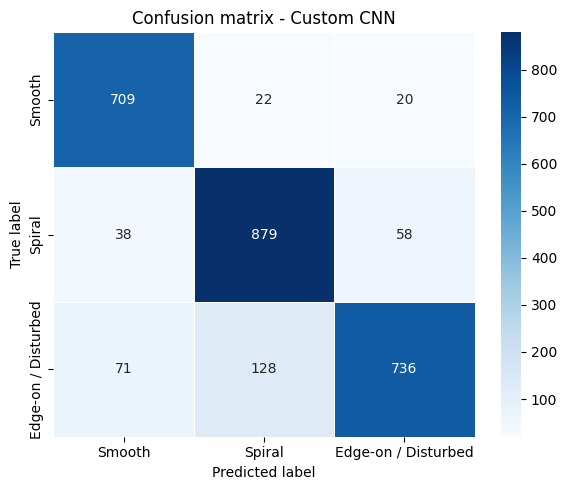

In [7]:
y_true_cnn, y_pred_cnn = evaluate(cnn, test_dl)
cnn_acc = (y_true_cnn == y_pred_cnn).mean()
print(f"Custom CNN test accuracy: {cnn_acc*100:.1f}%\n")
print(classification_report(y_true_cnn, y_pred_cnn, target_names=CLASS_NAMES))
plot_confusion(y_true_cnn, y_pred_cnn, "Confusion matrix - Custom CNN", "cnn_confusion.png")

## 5. ResNet-18 fine-tuning

ResNet-18 was pretrained on ImageNet (1.2M images, 1000 classes). Its early layers
already detect edges, textures, and curves - the same low-level features that matter
for galaxy morphology. We swap the final layer for a 3-class head and fine-tune.

**Two-stage training:**
1. Freeze the backbone, train only the new head for 5 epochs (fast convergence)
2. Unfreeze the last two residual blocks and train everything at a lower lr


In [8]:
# resize transforms for ResNet (expects 224x224, ImageNet normalisation)
resnet_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])
resnet_val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

rn_train_dl = DataLoader(GalaxyDataset(X_train, y_train, resnet_train_tf),
                         batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
rn_val_dl   = DataLoader(GalaxyDataset(X_val,   y_val,   resnet_val_tf),
                         batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
rn_test_dl  = DataLoader(GalaxyDataset(X_test,  y_test,  resnet_val_tf),
                         batch_size=32, shuffle=False, num_workers=0, pin_memory=True)


In [9]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# replace the final FC layer - 512 features in, 3 classes out
resnet.fc = nn.Linear(512, 3)
resnet = resnet.to(device)

# stage 1: freeze backbone, train head only
for name, param in resnet.named_parameters():
    if "fc" not in name:
        param.requires_grad = False

print("Stage 1: head only (5 epochs) ...")
_ = train_model(resnet, rn_train_dl, rn_val_dl, epochs=5, lr=1e-3, label="ResNet-head")

# stage 2: unfreeze last two residual blocks + head
for name, param in resnet.named_parameters():
    if any(layer in name for layer in ["layer3", "layer4", "fc"]):
        param.requires_grad = True

print("\nStage 2: layer3 + layer4 + head (25 epochs) ...")
rn_history = train_model(resnet, rn_train_dl, rn_val_dl, epochs=25, lr=3e-4, label="ResNet-ft")
torch.save(resnet.state_dict(), "../checkpoints/resnet18_finetuned.pth")

Stage 1: head only (5 epochs) ...
[ResNet-head] epoch   5  loss 0.6627/0.6725  acc 0.721/0.723  (44.2s)

Best val acc: 0.7242

Stage 2: layer3 + layer4 + head (25 epochs) ...
[ResNet-ft] epoch   5  loss 0.3230/0.3087  acc 0.879/0.877  (43.8s)
[ResNet-ft] epoch  10  loss 0.2724/0.2861  acc 0.901/0.894  (44.4s)
[ResNet-ft] epoch  15  loss 0.2222/0.3055  acc 0.919/0.890  (44.0s)
[ResNet-ft] epoch  20  loss 0.1717/0.2647  acc 0.937/0.902  (43.4s)
[ResNet-ft] epoch  25  loss 0.1468/0.2715  acc 0.946/0.903  (45.3s)

Best val acc: 0.9072


ResNet-18 test accuracy: 89.6%

                     precision    recall  f1-score   support

             Smooth       0.90      0.94      0.92       751
             Spiral       0.88      0.91      0.90       975
Edge-on / Disturbed       0.90      0.85      0.87       935

           accuracy                           0.90      2661
          macro avg       0.90      0.90      0.90      2661
       weighted avg       0.90      0.90      0.90      2661



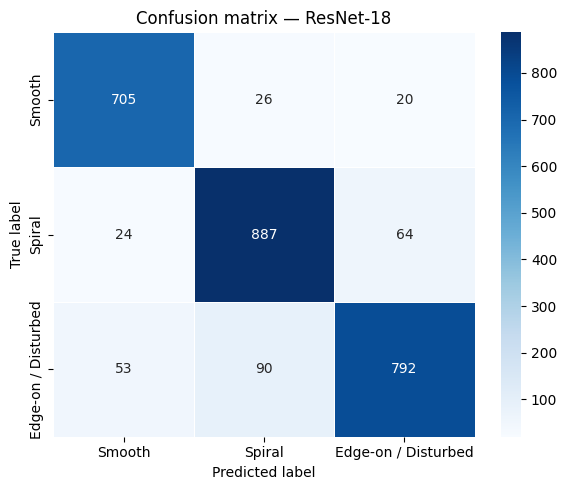

In [10]:
y_true_rn, y_pred_rn = evaluate(resnet, rn_test_dl)
rn_acc = (y_true_rn == y_pred_rn).mean()
print(f"ResNet-18 test accuracy: {rn_acc*100:.1f}%\n")
print(classification_report(y_true_rn, y_pred_rn, target_names=CLASS_NAMES))
plot_confusion(y_true_rn, y_pred_rn, "Confusion matrix — ResNet-18", "resnet_confusion.png")

## 6. Model comparison

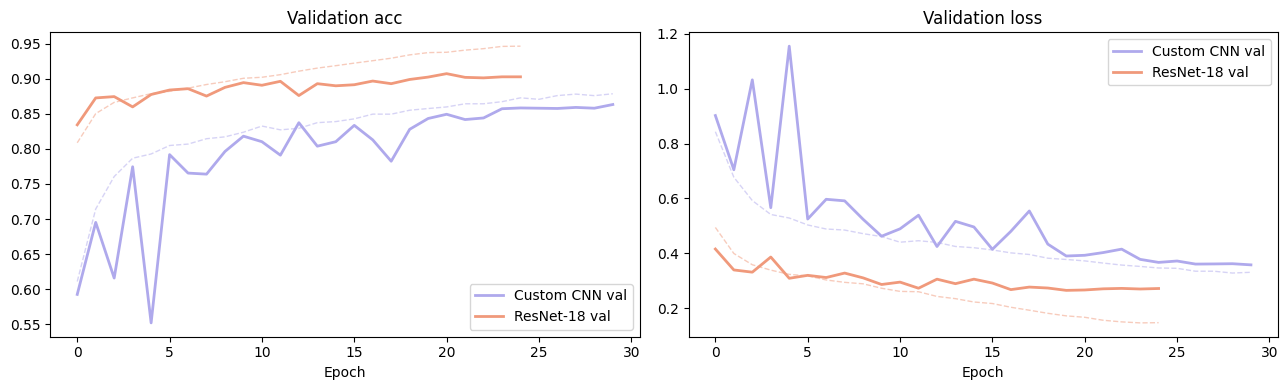

In [11]:
# training curves side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = {"CNN": "#AFA9EC", "ResNet": "#F0997B"}

for ax, metric in zip(axes, ["acc", "loss"]):
    ax.plot(cnn_history[f"val_{metric}"],    color=colors["CNN"],    linewidth=2, label="Custom CNN val")
    ax.plot(rn_history[f"val_{metric}"],     color=colors["ResNet"], linewidth=2, label="ResNet-18 val")
    ax.plot(cnn_history[f"train_{metric}"],  color=colors["CNN"],    linewidth=1, linestyle="--", alpha=0.5)
    ax.plot(rn_history[f"train_{metric}"],   color=colors["ResNet"], linewidth=1, linestyle="--", alpha=0.5)
    ax.set_title(f"Validation {metric}")
    ax.set_xlabel("Epoch")
    ax.legend()

plt.tight_layout()
plt.savefig("../results/model_comparison_curves.png", bbox_inches="tight")
plt.show()

In [12]:
# summary table
mlp_acc = 0.758

print()
print(f"{'Model':<20} {'Params':>10} {'Test Acc':>10}")
print()
print(f"{'NumPy MLP':<20} {'1,082,115':>10} {mlp_acc*100:>9.1f}%")
print(f"{'Custom CNN':<20} {sum(p.numel() for p in cnn.parameters()):>10,} {cnn_acc*100:>9.1f}%")
print(f"{'ResNet-18 (ft)':<20} {sum(p.numel() for p in resnet.parameters()):>10,} {rn_acc*100:>9.1f}%")
print()

print("\nKey takeaways:")
print(f"  CNN vs MLP gain   : +{(cnn_acc - mlp_acc)*100:.1f} percentage points")
print(f"  ResNet vs CNN gain: +{(rn_acc - cnn_acc)*100:.1f} percentage points")
print("  The CNN jump shows spatial features matter (spiral arms, elongation)")
print("  The ResNet jump shows ImageNet pre-training transfers to galaxy images")


Model                    Params   Test Acc

NumPy MLP             1,082,115      75.8%
Custom CNN              422,179      87.3%
ResNet-18 (ft)       11,178,051      89.6%


Key takeaways:
  CNN vs MLP gain   : +11.5 percentage points
  ResNet vs CNN gain: +2.3 percentage points
  The CNN jump shows spatial features matter (spiral arms, elongation)
  The ResNet jump shows ImageNet pre-training transfers to galaxy images
